# Thesis data overview: acquisition + POC findings

This notebook summarizes where the project stands:

1. **Acquisition (part 1)** — 613 company-fiscal-year DFP filings pulled from CVM for the 66 non-financial Ibovespa constituents, 2015–2024.
2. **POC** — on 20 sector-diverse companies from that set, does isolating the debt note ("empréstimos, financiamentos e debêntures") and comparing it year-over-year with TF-IDF + cosine similarity produce a sane signal?

Full narrative writeup: [`reports/poc_note_extraction_findings.md`](../reports/poc_note_extraction_findings.md). Pipeline code: [`src/acquisition/`](../src/acquisition/), [`src/processing/`](../src/processing/).

**Status: two rounds.** Round 1 established the concept works but flagged note-*isolation* as the weak link. Round 2 fixed four concrete, generalizable extraction bugs found by chasing the round-1 outliers to ground in the actual PDFs — the reliable-cohort mean rose from 0.75 to 0.87 and every exact-zero degenerate score disappeared. This notebook reflects round 2.

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import pandas as pd

ROOT = Path("..")
DATA = ROOT / "data" / "interim"

# Fixed categorical order (never cycled/reassigned) + one-hue sequential ramp,
# per the project's dataviz conventions.
BLUE, ORANGE, AQUA, YELLOW, MAGENTA, GREEN, VIOLET, RED = (
    "#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300", "#4a3aa7", "#e34948",
)
TEXT_PRIMARY, TEXT_SECONDARY, GRID = "#0b0b0b", "#52514e", "#e3e2dd"

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": GRID,
    "axes.grid": True,
    "grid.color": GRID,
    "grid.linewidth": 0.8,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "text.color": TEXT_PRIMARY,
    "axes.labelcolor": TEXT_SECONDARY,
    "xtick.color": TEXT_SECONDARY,
    "ytick.color": TEXT_SECONDARY,
    "font.size": 11,
})

DIAG_COLORS = {"font_heading": AQUA, "regex_only": YELLOW, "not_found": RED}
DIAG_LABELS = {"font_heading": "Precisely bounded", "regex_only": "Imprecise fallback", "not_found": "Not found"}

## 1. Acquisition (part 1): what's in the corpus

Non-financial Ibovespa constituents, 2015–2024 DFP filings, pulled from CVM's open-data portal + RAD system (see `src/acquisition/`).

In [2]:
universe = pd.read_csv(DATA / "ibov_non_financial_universe.csv")
log = pd.read_csv(DATA / "ibov_notes_download_log.csv")

n_companies = universe["CD_CVM"].nunique()
n_ok = (log["n_attachments_matched"] > 0).sum()
n_total = len(log)

print(f"{n_companies} non-financial Ibovespa companies")
print(f"{n_ok}/{n_total} company-fiscal-year filings acquired ({n_ok/n_total:.1%})")
print(f"Years covered: {log['ANO'].min()}–{log['ANO'].max()}")

66 non-financial Ibovespa companies
613/613 company-fiscal-year filings acquired (100.0%)
Years covered: 2015–2024


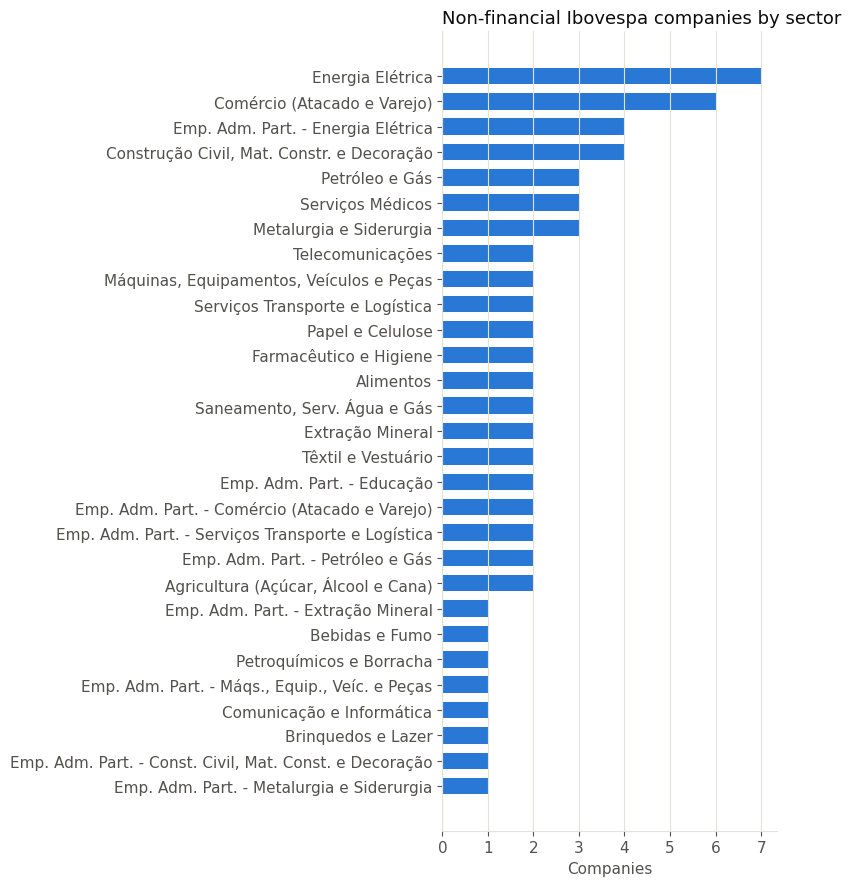

In [3]:
# Companies by sector -- one hue (categorical identity isn't the point here,
# magnitude is), horizontal so the Portuguese sector names stay readable.
sector_counts = (
    universe.drop_duplicates("CD_CVM")["SETOR_ATIV"]
    .value_counts()
    .sort_values(ascending=True)
)

fig, ax = plt.subplots(figsize=(8, 9))
ax.barh(sector_counts.index, sector_counts.values, color=BLUE, height=0.65)
ax.set_xlabel("Companies")
ax.set_title("Non-financial Ibovespa companies by sector", loc="left", fontsize=13, color=TEXT_PRIMARY)
ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
ax.grid(axis="y", visible=False)
fig.tight_layout()
plt.show()

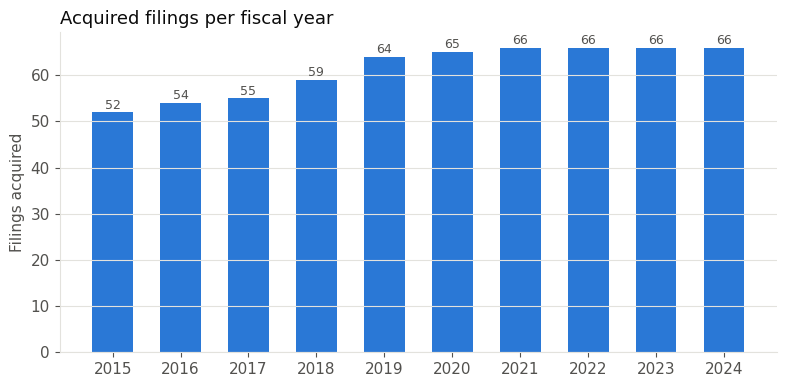

In [4]:
# Filings acquired per fiscal year -- magnitude over an ordered axis, single hue.
by_year = log[log["n_attachments_matched"] > 0].groupby("ANO").size()

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(by_year.index.astype(str), by_year.values, color=BLUE, width=0.6)
ax.set_ylabel("Filings acquired")
ax.set_title("Acquired filings per fiscal year", loc="left", fontsize=13, color=TEXT_PRIMARY)
ax.grid(axis="x", visible=False)
for x, y in zip(by_year.index.astype(str), by_year.values):
    ax.text(x, y + 0.8, str(y), ha="center", fontsize=9, color=TEXT_SECONDARY)
fig.tight_layout()
plt.show()

## 2. POC: can the debt note be isolated automatically?

20 sector-diverse companies × up to 10 years = 200 company-years, checked against the note-locator in `src/processing/locate_note_section.py`. Three outcomes:

- **`font_heading`** — found a heading visually distinct from body text (bold + larger font). Reliable.
- **`regex_only`** — no visually distinct heading; fell back to "last keyword mention, capped at 500 lines." Imprecise.
- **`not_found`** — no debt-note mention matched at all.

In [5]:
POC = DATA / "poc"

sections = pd.DataFrame(
    json.loads(p.read_text(encoding="utf-8")) for p in sorted((POC / "sections").glob("*.json"))
)
sections["chars"] = sections["text"].str.len()

diag_counts = sections["diagnostic"].value_counts().reindex(["font_heading", "regex_only", "not_found"])
for diag, n in diag_counts.items():
    print(f"{DIAG_LABELS[diag]:22s} {n:3d}/{len(sections)}  ({n/len(sections):.0%})")

Precisely bounded      229/500  (46%)
Imprecise fallback     226/500  (45%)
Not found               45/500  (9%)


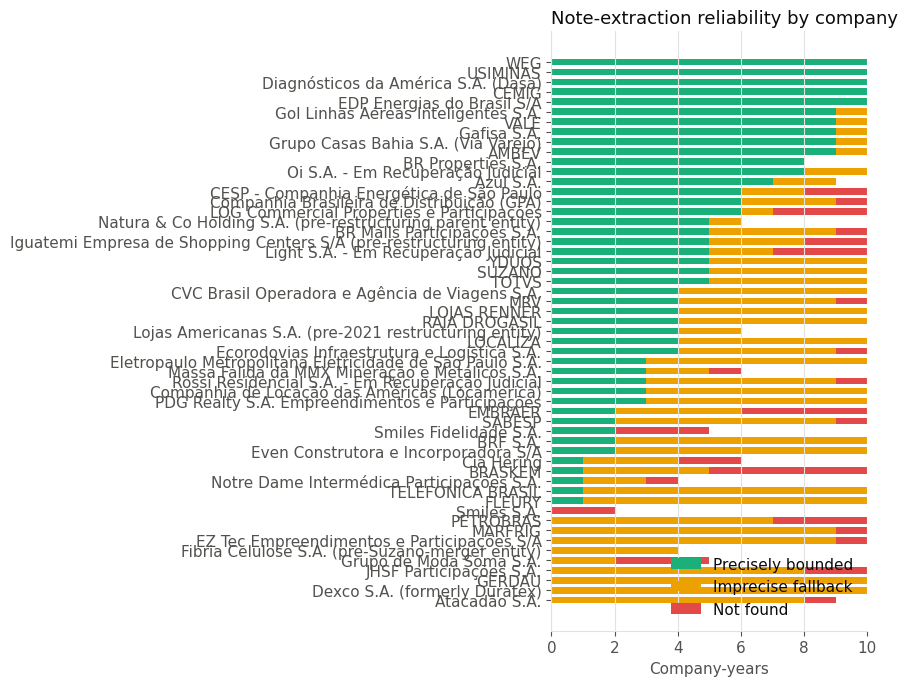

In [6]:
# Per-company reliability, ordered by how often extraction succeeded cleanly --
# status-style colors (green=reliable, amber=imprecise, red=missing), fixed order.
pivot = (
    sections.groupby(["name", "diagnostic"]).size().unstack(fill_value=0)
    .reindex(columns=["font_heading", "regex_only", "not_found"], fill_value=0)
)
pivot = pivot.loc[pivot["font_heading"].sort_values().index]

fig, ax = plt.subplots(figsize=(9, 7))
left = pd.Series(0, index=pivot.index)
for diag in ["font_heading", "regex_only", "not_found"]:
    ax.barh(pivot.index, pivot[diag], left=left, color=DIAG_COLORS[diag], label=DIAG_LABELS[diag], height=0.65)
    left = left + pivot[diag]

ax.set_xlabel("Company-years")
ax.set_title("Note-extraction reliability by company", loc="left", fontsize=13, color=TEXT_PRIMARY)
ax.legend(loc="lower right", frameon=False)
ax.grid(axis="y", visible=False)
fig.tight_layout()
plt.show()

## 3. Does the similarity measure make sense?

Year-over-year TF-IDF cosine similarity, fit across the whole POC corpus so IDF reflects cross-sectional boilerplate (the same logic the literature relies on). Comparing **all pairs** to pairs where **both years got a reliable extraction** shows the distribution tightening up substantially once extraction noise is controlled for.

In [7]:
results = pd.read_csv(POC / "similarity_results.csv")
both_reliable = results[(results["diagnostic_prev"] == "font_heading") & (results["diagnostic_curr"] == "font_heading")]

print("All pairs:            n={:3d}  mean={:.2f}  median={:.2f}".format(
    len(results), results["cosine_similarity"].mean(), results["cosine_similarity"].median()))
print("Both years reliable:  n={:3d}  mean={:.2f}  median={:.2f}".format(
    len(both_reliable), both_reliable["cosine_similarity"].mean(), both_reliable["cosine_similarity"].median()))

All pairs:            n=165  mean=0.63  median=0.81
Both years reliable:  n= 64  mean=0.87  median=0.92


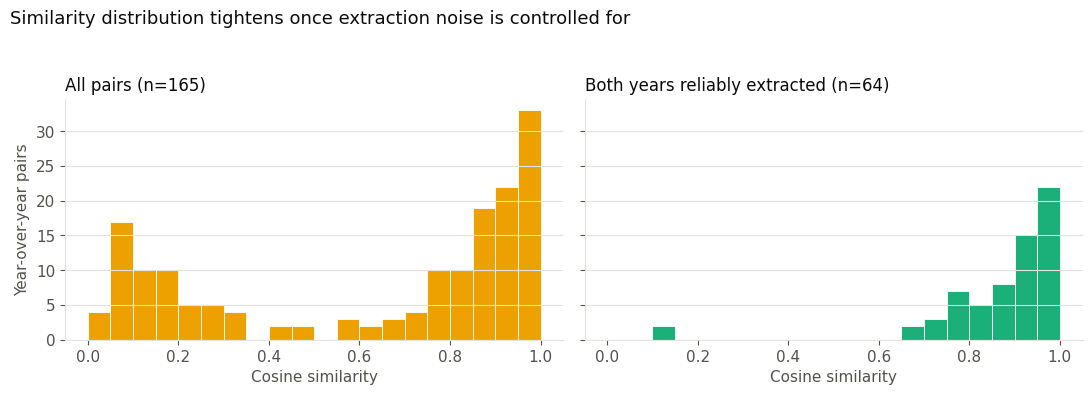

In [8]:
# Small multiples (same measure, two filters) rather than an overlaid
# histogram -- cleaner to compare than two semi-transparent fills.
bins = [i / 20 for i in range(21)]
fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True, sharex=True)

axes[0].hist(results["cosine_similarity"], bins=bins, color=YELLOW, edgecolor="white", linewidth=0.6)
axes[0].set_title(f"All pairs (n={len(results)})", loc="left", fontsize=12, color=TEXT_PRIMARY)

axes[1].hist(both_reliable["cosine_similarity"], bins=bins, color=AQUA, edgecolor="white", linewidth=0.6)
axes[1].set_title(f"Both years reliably extracted (n={len(both_reliable)})", loc="left", fontsize=12, color=TEXT_PRIMARY)

for ax in axes:
    ax.set_xlabel("Cosine similarity")
    ax.grid(axis="x", visible=False)
axes[0].set_ylabel("Year-over-year pairs")
fig.suptitle("Similarity distribution tightens once extraction noise is controlled for", x=0.01, ha="left", fontsize=13, color=TEXT_PRIMARY)
fig.tight_layout(rect=[0, 0, 1, 0.94])
plt.show()

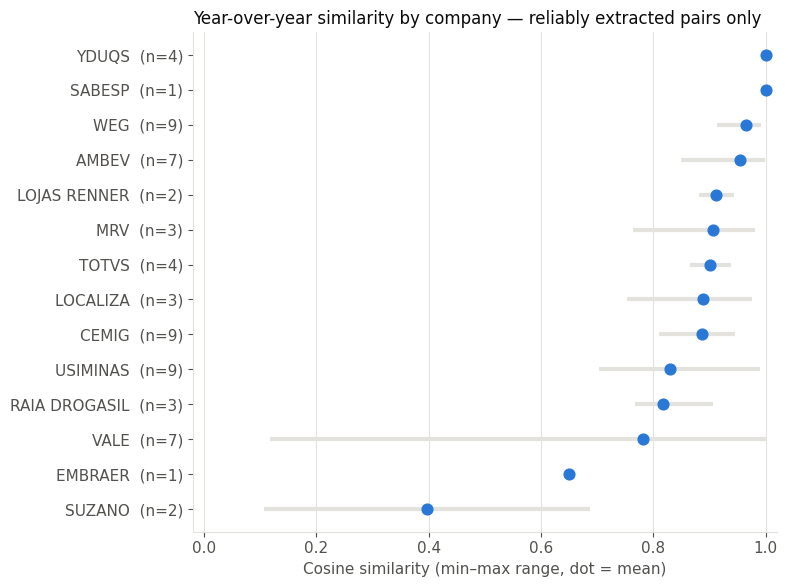

In [9]:
# Per-company mean similarity with min-max range, reliable pairs only.
# Sequential magnitude -> single hue; error bars show within-company spread.
by_company = (
    both_reliable.groupby("name")["cosine_similarity"]
    .agg(["mean", "min", "max", "count"])
    .sort_values("mean")
)

fig, ax = plt.subplots(figsize=(8, 6))
y = range(len(by_company))
ax.hlines(y, by_company["min"], by_company["max"], color=GRID, linewidth=3, zorder=1)
ax.scatter(by_company["mean"], y, color=BLUE, s=60, zorder=2, label="Mean")
ax.set_yticks(list(y))
ax.set_yticklabels([f"{n}  (n={c})" for n, c in zip(by_company.index, by_company["count"])])
ax.set_xlabel("Cosine similarity (min–max range, dot = mean)")
ax.set_title("Year-over-year similarity by company — reliably extracted pairs only", loc="left", fontsize=12, color=TEXT_PRIMARY)
ax.set_xlim(-0.02, 1.02)
ax.grid(axis="y", visible=False)
fig.tight_layout()
plt.show()

## 4. Case studies: is the signal real?

Numbers alone can't answer this — reading the actual extracted text can. Two cases below: a genuine high-similarity pair (real content, real stability) and a degenerate one (extraction artifact, not a real "no change" finding).

In [10]:
import difflib


def show_pair(cd_cvm, year_prev, year_curr, n_diff_lines=16):
    d1 = json.loads((POC / "sections" / f"{cd_cvm}_{year_prev}.json").read_text(encoding="utf-8"))
    d2 = json.loads((POC / "sections" / f"{cd_cvm}_{year_curr}.json").read_text(encoding="utf-8"))
    row = results[(results["cd_cvm"] == int(cd_cvm)) & (results["year_prev"] == year_prev) & (results["year_curr"] == year_curr)].iloc[0]
    print(f"{d1['name']}: {year_prev} ({len(d1['text'])} chars) -> {year_curr} ({len(d2['text'])} chars)")
    print(f"cosine similarity = {row['cosine_similarity']:.4f}\n")
    diff = list(difflib.unified_diff(d1["text"].splitlines(), d2["text"].splitlines(), lineterm="", n=0))
    for line in diff[2 : 2 + n_diff_lines]:
        print(line)


print("### Genuine high similarity: WEG 2015 -> 2016 ###\n")
show_pair("005410", 2015, 2016)

### Genuine high similarity: WEG 2015 -> 2016 ###

WEG: 2015 (2516 chars) -> 2016 (2501 chars)
cosine similarity = 0.9918

@@ -1 +1 @@
-14 Financiamentos e empréstimos
+14 Empréstimos e Financiamentos
@@ -5 +5 @@
-líquida/ EBITDA, inclusas nos contratos com o BNDES, estão sendo atendidas.
+líquida/EBITDA, inclusas nos contratos com o BNDES, estão sendo atendidas.
@@ -7,2 +7,2 @@
-Encargos Anuais em 31/12/15
-NO BRASIL
+Encargos Anuais em 31/12/16
+EM MOEDA NACIONAL
@@ -10,2 +10,2 @@
-736.784
-1.086.642
+642.413
+637.552


In [11]:
print("### Extraction artifact, not a real finding: Yduqs (identical 648-char text, 4 different year-pairs) ###\n")
d = json.loads((POC / "sections" / "021016_2015.json").read_text(encoding="utf-8"))
print(f"Heading found: {d['heading']!r}\n")
print(d["text"])
print("\n^ This is a generic IFRS accounting-POLICY paragraph, not the actual note (Yduqs numbers the real")
print("  note separately, as 'Nota 11', found only in later years). Same text recurs across 2015-2019,")
print("  producing cosine similarity = 1.0000 -- a false 'no change' signal, not a real finding.")

### Extraction artifact, not a real finding: Yduqs (identical 648-char text, 4 different year-pairs) ###

Heading found: 'Empréstimos e financiamentos'

Empréstimos e financiamentos
Os empréstimos são reconhecidos, inicialmente, pelo valor justo, líquido dos custos incorridos
na transação e são, subsequentemente, demonstrados pelo custo amortizado. Qualquer
diferença entre os valores captados (líquidos dos custos da transação) e o valor total a pagar é
reconhecida na demonstração do resultado durante o período em que os empréstimos estejam
em aberto, utilizando o método da taxa efetiva de juros.
Os empréstimos são classificados como passivo circulante, a menos que o Grupo tenha um
direito incondicional de diferir a liquidação do passivo por, pelo menos, 12 meses após a data do
balanço.
2.15

^ This is a generic IFRS accounting-POLICY paragraph, not the actual note (Yduqs numbers the real
  note separately, as 'Nota 11', found only in later years). Same text recurs across 2015-2019,
  p

## 5. Survivorship bias check: does dropping out of IBOV correlate with textual change?

Part 1's acquisition originally only covered *today's* 66 non-financial IBOV constituents — a real survivorship-bias problem, since a company that went bankrupt, got acquired, or was delisted mid-sample would be entirely absent, and those are exactly the companies most likely to show large debt-note textual change. That gap is now closed: 36 more companies were found that were IBOV members at some point in 2015–2024 but aren't today (26 via Internet Archive snapshots of B3's retired portfolio page, 10 more via a Bloomberg historical-composition export), documented in [`src/acquisition/b3_ibov_historical.py`](../src/acquisition/b3_ibov_historical.py). Several are directly on-theme: Oi, Light, and Rossi Residencial are all currently in *recuperação judicial*; MMX Mineração is a bankruptcy estate.

This section asks the natural next question: run the same note-extraction + TF-IDF pipeline on this "dropped or delisted" group and compare it to the "stayed" group (the original 20 POC companies) — is there a difference in textual change?

In [12]:
delisted_results = pd.read_csv(POC / "delisted_similarity_results.csv")
delisted_reliable = delisted_results[
    (delisted_results["diagnostic_prev"] == "font_heading") & (delisted_results["diagnostic_curr"] == "font_heading")
].copy()
delisted_reliable["size_ratio"] = (
    delisted_reliable[["chars_prev", "chars_curr"]].min(axis=1) / delisted_reliable[["chars_prev", "chars_curr"]].max(axis=1)
)

n_delisted_companies = delisted_results.loc[delisted_results["group"] == "dropped_or_delisted", "cd_cvm"].nunique()
print(f"{n_delisted_companies} dropped-or-delisted companies checked, {len(delisted_results)} year-over-year pairs total\n")

summary = delisted_reliable.groupby("group")["cosine_similarity"].agg(["count", "mean", "median", "std"])
print("Reliable (font_heading/font_heading) pairs only:")
print(summary.round(3))

34 dropped-or-delisted companies checked, 401 year-over-year pairs total

Reliable (font_heading/font_heading) pairs only:
                     count   mean  median    std
group                                           
dropped_or_delisted    104  0.742   0.866  0.288
stayed                  64  0.876   0.924  0.161


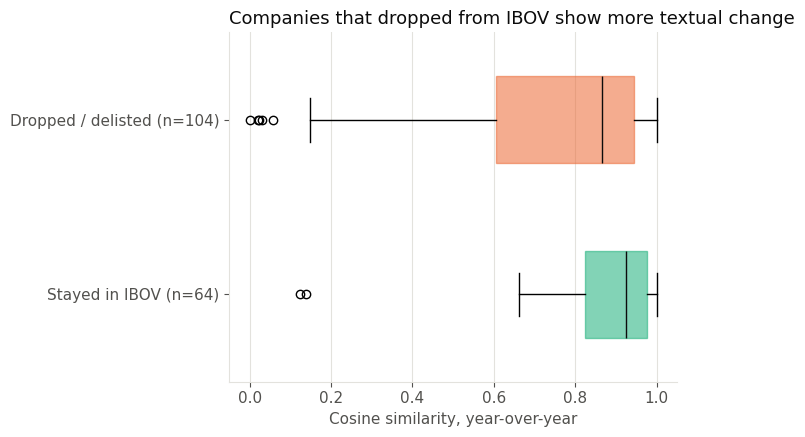

In [13]:
# Two groups, one measure -> box plot, fixed categorical order (stayed
# first, matching every other chart's "reliable/good" -> aqua convention).
GROUP_ORDER = ["stayed", "dropped_or_delisted"]
GROUP_LABELS = {"stayed": "Stayed in IBOV", "dropped_or_delisted": "Dropped / delisted"}
GROUP_COLORS = {"stayed": AQUA, "dropped_or_delisted": ORANGE}

fig, ax = plt.subplots(figsize=(7, 4.5))
data = [delisted_reliable.loc[delisted_reliable["group"] == g, "cosine_similarity"] for g in GROUP_ORDER]
bp = ax.boxplot(data, vert=False, widths=0.5, patch_artist=True, medianprops={"color": TEXT_PRIMARY})
for patch, g in zip(bp["boxes"], GROUP_ORDER):
    patch.set_facecolor(GROUP_COLORS[g])
    patch.set_alpha(0.55)
    patch.set_edgecolor(GROUP_COLORS[g])
ax.set_yticks([1, 2])
ax.set_yticklabels([f"{GROUP_LABELS[g]} (n={len(d)})" for g, d in zip(GROUP_ORDER, data)])
ax.set_xlabel("Cosine similarity, year-over-year")
ax.set_title("Companies that dropped from IBOV show more textual change", loc="left", fontsize=13, color=TEXT_PRIMARY)
ax.grid(axis="y", visible=False)
fig.tight_layout()
plt.show()

**Before trusting this, apply the same skepticism as everywhere else in this notebook.** The "dropped/delisted" group is newer to the pipeline and hasn't had the same round-2 hardening the original 20 companies got (§2), so some of its lower similarity could be extraction noise rather than genuine textual change. Restricting to pairs where the extracted note length is reasonably consistent across both years (`size_ratio >= 0.5`, i.e. neither year's capture is wildly bigger or smaller than the other — a proxy for "the locator found comparable content both times") is a direct check of that.

In [14]:
from scipy import stats

def compare_groups(df, label):
    dropped = df.loc[df["group"] == "dropped_or_delisted", "cosine_similarity"]
    stayed = df.loc[df["group"] == "stayed", "cosine_similarity"]
    _, p = stats.mannwhitneyu(dropped, stayed, alternative="less")
    print(f"{label}")
    print(f"  dropped/delisted: n={len(dropped):3d}  mean={dropped.mean():.3f}  median={dropped.median():.3f}")
    print(f"  stayed:           n={len(stayed):3d}  mean={stayed.mean():.3f}  median={stayed.median():.3f}")
    print(f"  Mann-Whitney U (dropped < stayed), one-sided: p = {p:.4f}\n")

compare_groups(delisted_reliable, "All reliable pairs:")
compare_groups(delisted_reliable[delisted_reliable["size_ratio"] >= 0.5], "Restricted to size-consistent pairs (size_ratio >= 0.5):")

All reliable pairs:
  dropped/delisted: n=104  mean=0.742  median=0.866
  stayed:           n= 64  mean=0.876  median=0.924
  Mann-Whitney U (dropped < stayed), one-sided: p = 0.0028

Restricted to size-consistent pairs (size_ratio >= 0.5):
  dropped/delisted: n= 81  mean=0.859  median=0.905
  stayed:           n= 60  mean=0.904  median=0.926
  Mann-Whitney U (dropped < stayed), one-sided: p = 0.0679



**Reading:** the effect survives the stricter filter directionally (dropped/delisted still lower on average) but is noticeably weaker and no longer conventionally significant (p rises well above 0.05) — meaning part of the raw gap above genuinely is extraction noise specific to this newer company set, not pure signal. This is a real, suggestive result, not yet a settled one: worth the same round-2-style hardening work before leaning on it for the thesis. Two concrete examples below show both sides of that honestly.

In [15]:
def show_delisted_pair(cd_cvm, year_prev, year_curr, n_diff_lines=20):
    cd_cvm_str = f"{int(cd_cvm):06d}"
    d1 = json.loads((POC / "sections" / f"{cd_cvm_str}_{year_prev}.json").read_text(encoding="utf-8"))
    d2 = json.loads((POC / "sections" / f"{cd_cvm_str}_{year_curr}.json").read_text(encoding="utf-8"))
    row = delisted_results[
        (delisted_results["cd_cvm"] == int(cd_cvm)) & (delisted_results["year_prev"] == year_prev) & (delisted_results["year_curr"] == year_curr)
    ].iloc[0]
    print(f"{d1['name']}: {year_prev} ({len(d1['text'])} chars) -> {year_curr} ({len(d2['text'])} chars)")
    print(f"cosine similarity = {row['cosine_similarity']:.4f}\n")
    diff = list(difflib.unified_diff(d1["text"].splitlines(), d2["text"].splitlines(), lineterm="", n=0))
    for line in diff[2 : 2 + n_diff_lines]:
        print(line)


print("### Genuine signal: Grupo Casas Bahia (Via Varejo) 2023 -> 2024, during known financial distress ###\n")
show_delisted_pair(6505, 2023, 2024)

### Genuine signal: Grupo Casas Bahia (Via Varejo) 2023 -> 2024, during known financial distress ###

Grupo Casas Bahia S.A. (Via Varejo): 2023 (10433 chars) -> 2024 (9969 chars)
cosine similarity = 0.5767

@@ -4,3 +4,4 @@
-Taxa média
-Repasse para instituições financeiras – CDCI (i)
-18,31% a.a.
+Taxa média a.a.
+Repasse para instituições financeiras (“CDCI”) (i)
+19,23%
+5.377
@@ -8,16 +9,8 @@
-5.241
-Empréstimos em moeda nacional (ii)
-CDI + 4,00% a.a.
-398
-1.220
-Debêntures (iii)
-CDI + 2,59% a.a.
-3.234
-2.128
-Debêntures (iii) - 8ª Deb (Séries 2 e 3)
-IPCA + 8,79% a.a.


In [16]:
print("### Still an extraction artifact: MMX Mineração (bankruptcy estate) 2016 -> 2018 ###\n")
show_delisted_pair(17914, 2016, 2018)
print("\n^ Both years captured the generic accounting-POLICY paragraph again, not real bankruptcy-specific")
print("  disclosure -- same failure mode as the Yduqs example in §4. A company literally in bankruptcy")
print("  proceedings is exactly the case where the real note would be most informative, and exactly the")
print("  case this pipeline currently fails on. Illustrates why the size-consistency filter above matters.")

### Still an extraction artifact: MMX Mineração (bankruptcy estate) 2016 -> 2018 ###

Massa Falida da MMX Mineração e Metálicos S.A.: 2016 (296 chars) -> 2018 (355 chars)
cosine similarity = 0.3634

@@ -1,6 +1,5 @@
-Empréstimos e financiamentos e debêntures
-Após reconhecimento inicial, empréstimos, financiamentos e debêntures
-sujeitos a juros são mensurados subsequentemente pelo custo amortizado,
-utilizando o método da taxa de juros efetivos. Ganhos e perdas são
-reconhecidos na demonstração do resultado.
-25
+3.10. Empréstimos e financiamentos
+São reconhecidos, inicialmente, pelo valor justo, líquido dos custos incorridos na transação
+e são, subsequentemente, demonstrados pelo custo amortizado, utilizando o método da taxa
+efetiva de juros. As taxas pagas no estabelecimento dos empréstimos e financiamentos são
+reconhecidas como custos da transação dos mesmos.

^ Both years captured the generic accounting-POLICY paragraph again, not real bankruptcy-specific
  disclosure -- same f

## Conclusion

**Go — and round 2 already improved the extraction step.** The similarity measure itself is sound and interpretable; round 1 traced every degenerate score to a specific, explainable extraction miss, not a flaw in the TF-IDF approach. Round 2 fixed four of those misses generally (see the report §5): a size-vs-purity tie-break bug, lettered-subsection markers colliding with Portuguese articles, table-of-contents entries mimicking real headings, and wrapped compound titles being cut short. Result: the reliable (`font_heading`) cohort's mean similarity rose from 0.75 to **0.87** with no more exact-zero artifacts, and Vale — the worst-behaved company in round 1 — is now stable across every year checked.

**The survivorship-bias fix (§5) surfaces a promising but not-yet-settled signal.** Companies that dropped out of IBOV or delisted show lower year-over-year similarity (more textual change) than companies that stayed, and the direction holds up under a stricter consistency filter — but the effect weakens and loses conventional significance under that filter, meaning part of the raw gap is extraction noise specific to this newer, less-hardened company set rather than pure signal. The Grupo Casas Bahia example shows the hoped-for pattern working exactly as intended (real debt restructuring, correctly detected); the MMX example shows the pipeline still failing in exactly the cases — companies in genuine distress — where getting it right matters most.

Still open (detailed in [`reports/poc_note_extraction_findings.md`](../reports/poc_note_extraction_findings.md) §5):
1. ~57% of company-years still don't get the precise `font_heading` extraction — Yduqs/Sabesp-style cases where the real note simply isn't styled distinctly need a different strategy (DFP index page, or an LLM fallback), not another heuristic tweak.
2. Add an automated red-flag check (exact 0/1 similarity, or notes under ~200 characters) so future runs surface likely extraction failures instead of silently feeding them into the analysis.
3. Extend round-2-style hardening to the 36 dropped/delisted companies specifically before leaning on the §5 finding for the thesis -- distressed companies' filings are exactly the hardest case (irregular formats, mid-bankruptcy restructurings, inconsistent filers) and exactly the ones this result depends on getting right.